In [1]:
import json
import logging
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

In [2]:
DATA_PATH = Path("../data/training/training_dataset.parquet")   # notebook is inside notebooks/, so ../
FIGURES_DIR = Path("../reports/eda/figures")
STATS_PATH = Path("../reports/eda/eda_stats.json")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
STATS_PATH.parent.mkdir(parents=True, exist_ok=True)

POLLUTANT_COLS = ["pm25", "pm10", "no2", "so2", "co", "o3"]
WEATHER_COLS = ["temperature", "feels_like", "humidity", "pressure", "visibility", "wind_speed", "cloudiness"]
TARGET_COL = "aqi"
TIME_COL = "timestamp"
CITY_COL = "city"

all_stats = {}   # collects stats from every section, saved as JSON at the end

In [3]:
df = pd.read_parquet(DATA_PATH)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True, errors="coerce")

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 105054 rows, 31 columns


,city,country,latitude,longitude,timestamp,temperature,feels_like,humidity,pressure,visibility,...,o3,source,created_at,hour,day,month,day_of_week,is_weekend,aqi_change_rate,aqi_rolling_mean_3h
0,Islamabad,PK,33.6844,73.0479,2022-07-21 00:00:00+00:00,26.6,30.6,83,942,-1,...,79.07641,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,0.0,21.0,7.0,3.0,0.0,0.0,0.0
1,Islamabad,PK,33.6844,73.0479,2022-07-21 01:00:00+00:00,26.4,30.6,84,940,-1,...,79.07641,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,1.0,21.0,7.0,3.0,0.0,0.0,0.0
2,Islamabad,PK,33.6844,73.0479,2022-07-21 02:00:00+00:00,26.1,30.3,84,940,-1,...,79.07641,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,2.0,21.0,7.0,3.0,0.0,0.0,0.0
3,Islamabad,PK,33.6844,73.0479,2022-07-21 03:00:00+00:00,25.8,30.2,87,941,-1,...,79.07641,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,3.0,21.0,7.0,3.0,0.0,0.0,0.0
4,Islamabad,PK,33.6844,73.0479,2022-07-21 04:00:00+00:00,25.6,30.0,88,941,-1,...,79.07641,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,4.0,21.0,7.0,3.0,0.0,0.0,0.0


In [4]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105054 entries, 0 to 105053
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   city                 105054 non-null  object             
 1   country              105054 non-null  object             
 2   latitude             105054 non-null  float64            
 3   longitude            105054 non-null  float64            
 4   timestamp            105054 non-null  datetime64[ns, UTC]
 5   temperature          105054 non-null  float64            
 6   feels_like           105054 non-null  float64            
 7   humidity             105054 non-null  int64              
 8   pressure             105054 non-null  int64              
 9   visibility           105054 non-null  int64              
 10  wind_speed           105054 non-null  float64            
 11  wind_degree          105054 non-null  int64              
 12  cl

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
city,105054,3,Islamabad,35018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,105054,1,PK,105054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,105054.0,NaN,NaN,NaN,30.031601,24.8607,24.8607,31.5497,33.6844,33.7104,3.758819
longitude,105054.0,NaN,NaN,NaN,71.464203,67.0011,67.0011,73.0479,74.3436,74.3436,3.199926
timestamp,105054,NaN,NaN,NaN,2024-07-19 12:29:58.645192192+00:00,2022-07-21 00:00:00+00:00,2023-07-20 18:00:00+00:00,2024-07-19 12:30:00+00:00,2025-07-19 07:00:00+00:00,2026-07-18 23:00:00+00:00,NaN
temperature,105054.0,NaN,NaN,NaN,23.924174,1.1,18.6,25.5,29.3,46.5,7.570892
feels_like,105054.0,NaN,NaN,NaN,25.183866,-2.6,17.7,27.2,32.9,47.6,9.645793
humidity,105054.0,NaN,NaN,NaN,63.557218,5.0,48.0,66.0,81.0,100.0,21.486077
pressure,105054.0,NaN,NaN,NaN,980.128896,934.0,954.0,983.0,1002.0,1024.0,24.508805
visibility,105054.0,NaN,NaN,NaN,-0.428808,-1.0,-1.0,-1.0,-1.0,10000.0,75.579223


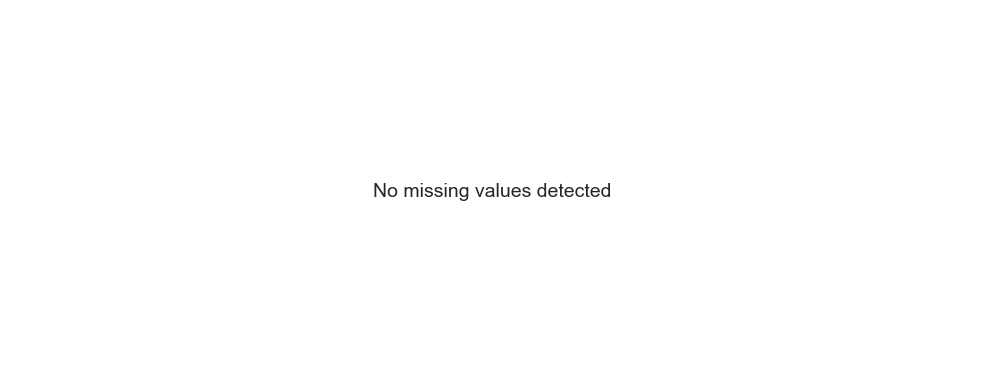

{}

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_stats = {
    col: {"missing_count": int(missing[col]), "missing_pct": float(missing_pct[col])}
    for col in df.columns
    if missing[col] > 0
}
all_stats["missing_values"] = missing_stats

fig, ax = plt.subplots(figsize=(10, max(4, len(missing_stats) * 0.35)))
if missing_stats:
    cols = list(missing_stats.keys())
    pct = [missing_stats[c]["missing_pct"] for c in cols]
    ax.barh(cols, pct, color="#d1495b")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Value Percentage by Column")
else:
    ax.text(0.5, 0.5, "No missing values detected", ha="center", va="center", fontsize=14)
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "missing_values.png", dpi=110, bbox_inches="tight")
plt.show()

missing_stats

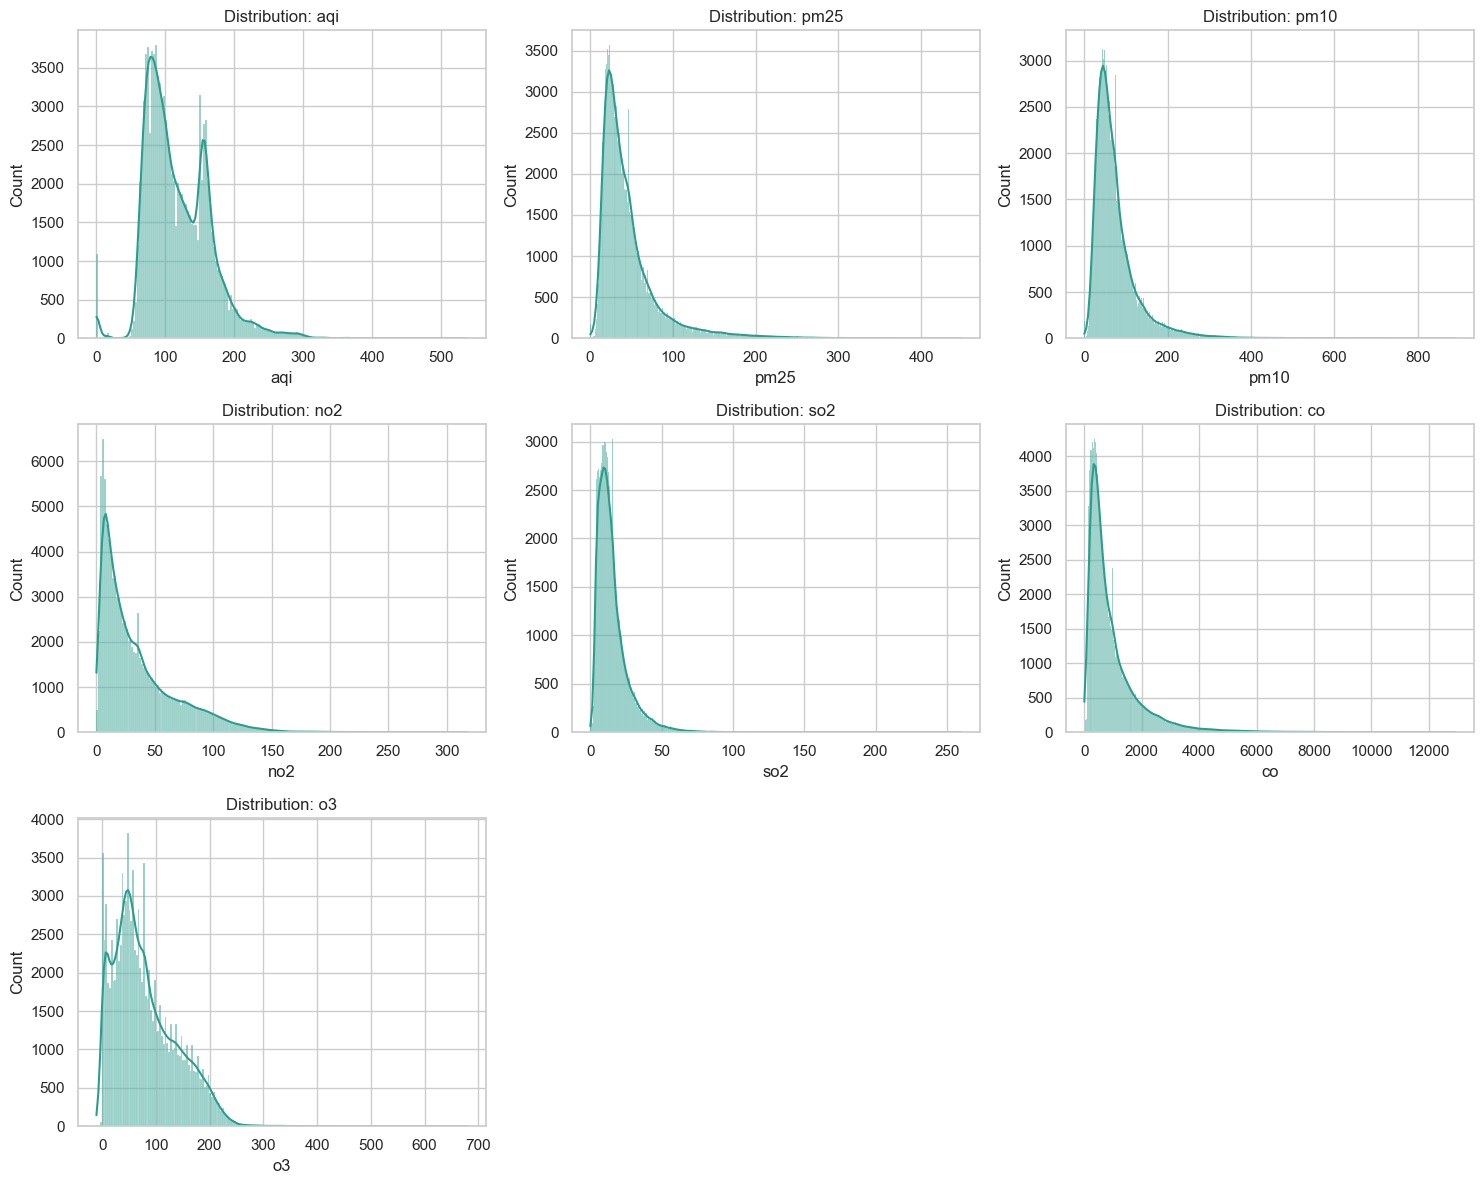

In [7]:
cols = [c for c in [TARGET_COL] + POLLUTANT_COLS if c in df.columns]
ncols = 3
nrows = (len(cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#2a9d8f")
    axes[i].set_title(f"Distribution: {col}")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "distributions.png", dpi=110, bbox_inches="tight")
plt.show()

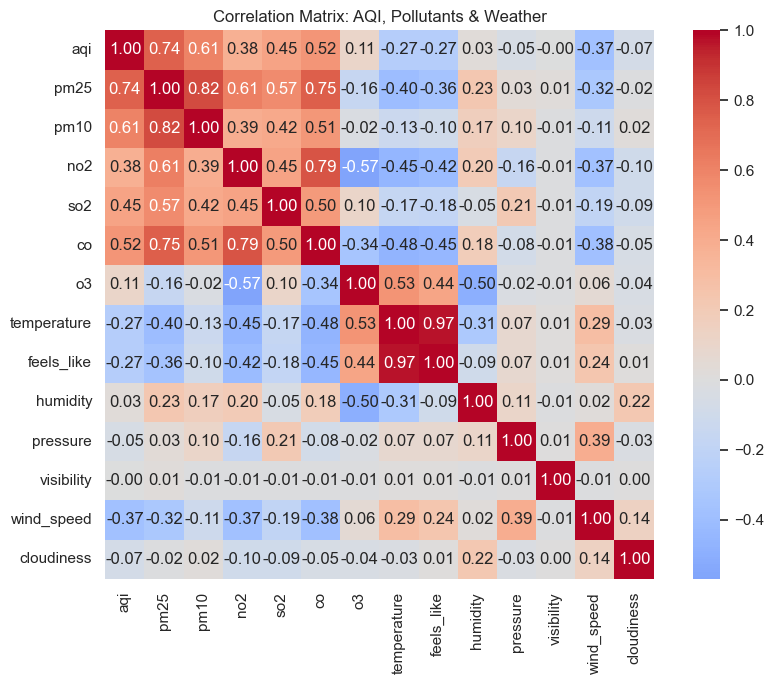

pm25           0.744284
pm10           0.605626
co             0.521938
so2            0.445458
no2            0.378940
wind_speed    -0.373558
temperature   -0.272129
feels_like    -0.268134
o3             0.111189
cloudiness    -0.072908
pressure      -0.052273
humidity       0.030099
visibility    -0.000317
Name: aqi, dtype: float64

In [8]:
numeric_cols = [c for c in [TARGET_COL] + POLLUTANT_COLS + WEATHER_COLS if c in df.columns]
corr = df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix: AQI, Pollutants & Weather")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

aqi_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
all_stats["aqi_correlations"] = {col: round(float(val), 4) for col, val in aqi_corr.items()}
aqi_corr

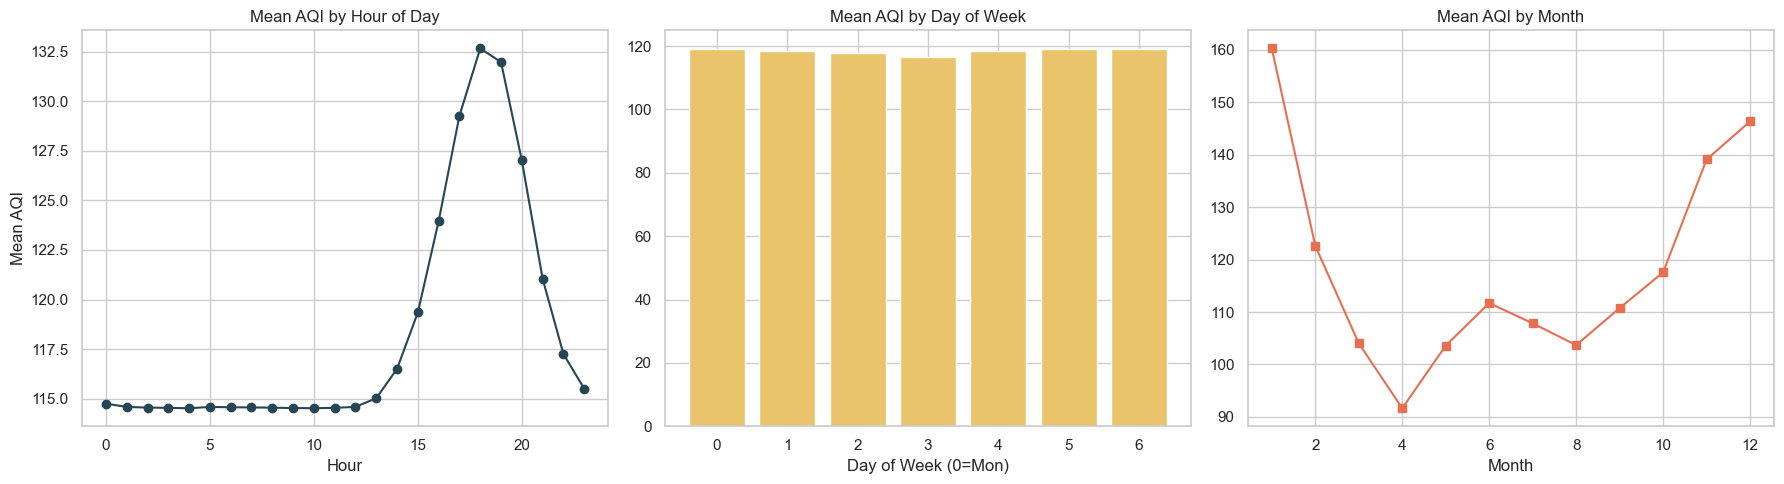

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if "hour" in df.columns:
    hourly = df.groupby("hour")[TARGET_COL].mean()
    axes[0].plot(hourly.index, hourly.values, marker="o", color="#264653")
    axes[0].set_title("Mean AQI by Hour of Day")
    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Mean AQI")

if "day_of_week" in df.columns:
    dow = df.groupby("day_of_week")[TARGET_COL].mean()
    axes[1].bar(dow.index, dow.values, color="#e9c46a")
    axes[1].set_title("Mean AQI by Day of Week")
    axes[1].set_xlabel("Day of Week (0=Mon)")

if "month" in df.columns:
    monthly = df.groupby("month")[TARGET_COL].mean()
    axes[2].plot(monthly.index, monthly.values, marker="s", color="#e76f51")
    axes[2].set_title("Mean AQI by Month")
    axes[2].set_xlabel("Month")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "seasonality.png", dpi=110, bbox_inches="tight")
plt.show()

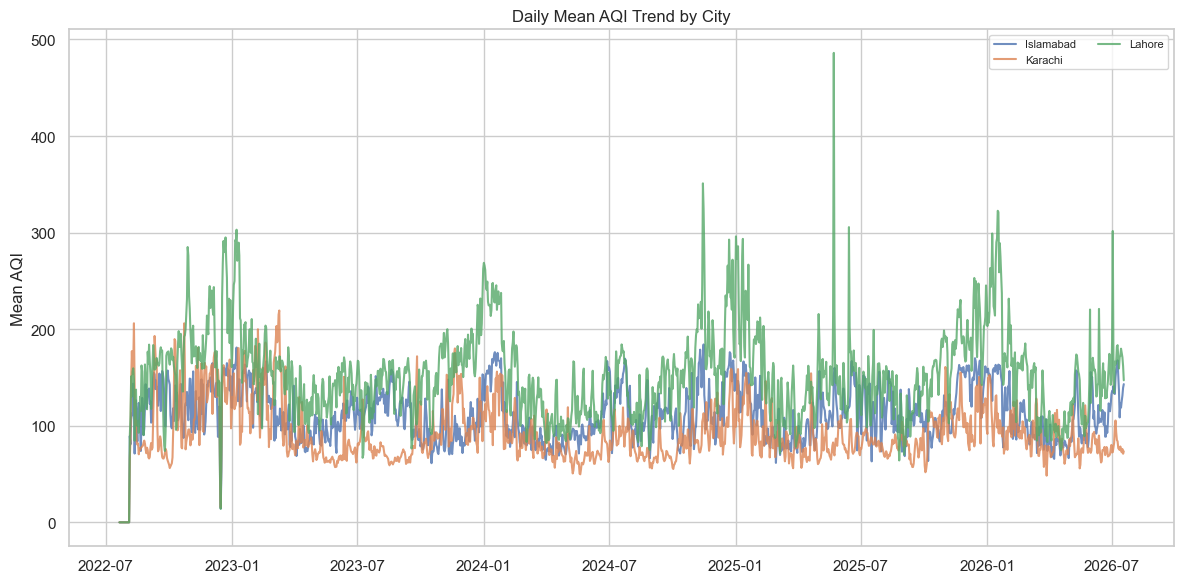

,mean,median,std,min,max,count
city,,,,,,
Islamabad,110.97,106.0,33.09,0,218,35018
Karachi,91.78,83.0,32.03,0,297,35018
Lahore,152.13,153.0,50.04,0,538,35018


In [10]:
city_summary = (
    df.groupby(CITY_COL)[TARGET_COL]
    .agg(["mean", "median", "std", "min", "max", "count"])
    .round(2)
)
all_stats["per_city_stats"] = city_summary.to_dict(orient="index")

fig, ax = plt.subplots(figsize=(12, 6))
for city, group in df.groupby(CITY_COL):
    daily = group.set_index(TIME_COL)[TARGET_COL].resample("1D").mean()
    ax.plot(daily.index, daily.values, label=city, alpha=0.8)
ax.set_title("Daily Mean AQI Trend by City")
ax.set_ylabel("Mean AQI")
ax.legend(loc="upper right", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "city_trends.png", dpi=110, bbox_inches="tight")
plt.show()

city_summary

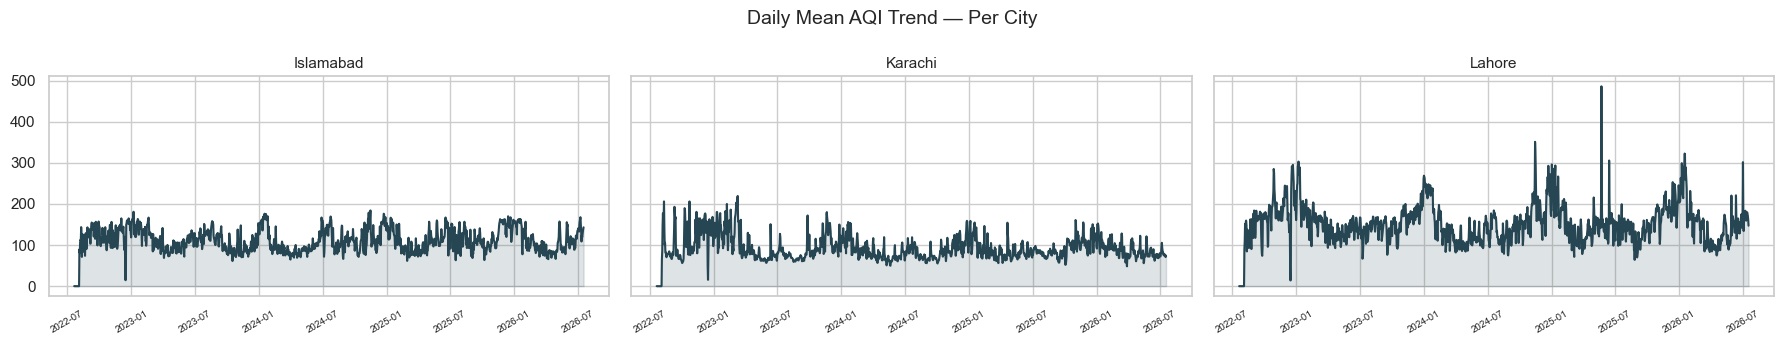

In [11]:
cities = sorted(df[CITY_COL].dropna().unique())
n_cities = len(cities)
ncols = 3
nrows = (n_cities + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows), sharey=True)
axes = axes.flatten()
for i, city in enumerate(cities):
    group = df[df[CITY_COL] == city]
    daily = group.set_index(TIME_COL)[TARGET_COL].resample("1D").mean()
    axes[i].plot(daily.index, daily.values, color="#264653")
    axes[i].fill_between(daily.index, daily.values, alpha=0.15, color="#264653")
    axes[i].set_title(city, fontsize=11)
    axes[i].tick_params(axis="x", rotation=30, labelsize=7)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Daily Mean AQI Trend — Per City", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "city_trend_grid.png", dpi=110, bbox_inches="tight")
plt.show()

D:\Temp\ipykernel_7936\3561423833.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=CITY_COL, y=TARGET_COL, order=order, ax=ax, palette="viridis")


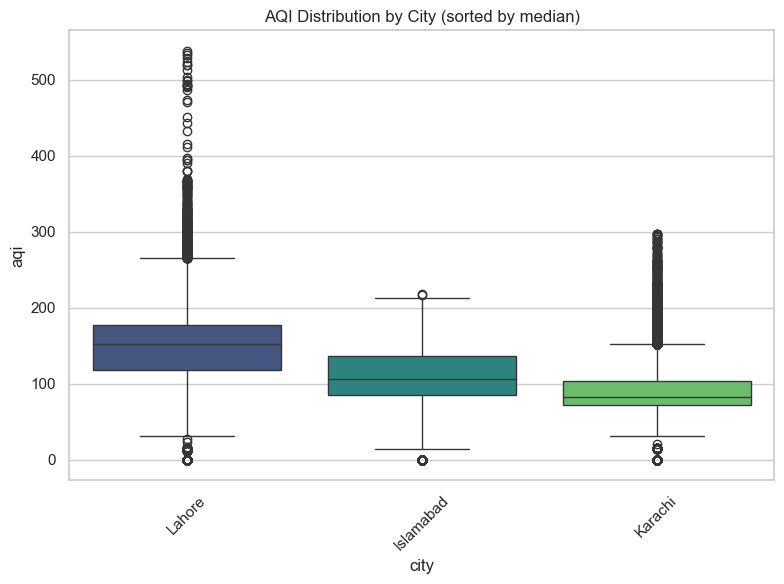

In [12]:
order = df.groupby(CITY_COL)[TARGET_COL].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(max(8, n_cities * 1.1), 6))
sns.boxplot(data=df, x=CITY_COL, y=TARGET_COL, order=order, ax=ax, palette="viridis")
ax.set_title("AQI Distribution by City (sorted by median)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "city_aqi_boxplot.png", dpi=110, bbox_inches="tight")
plt.show()

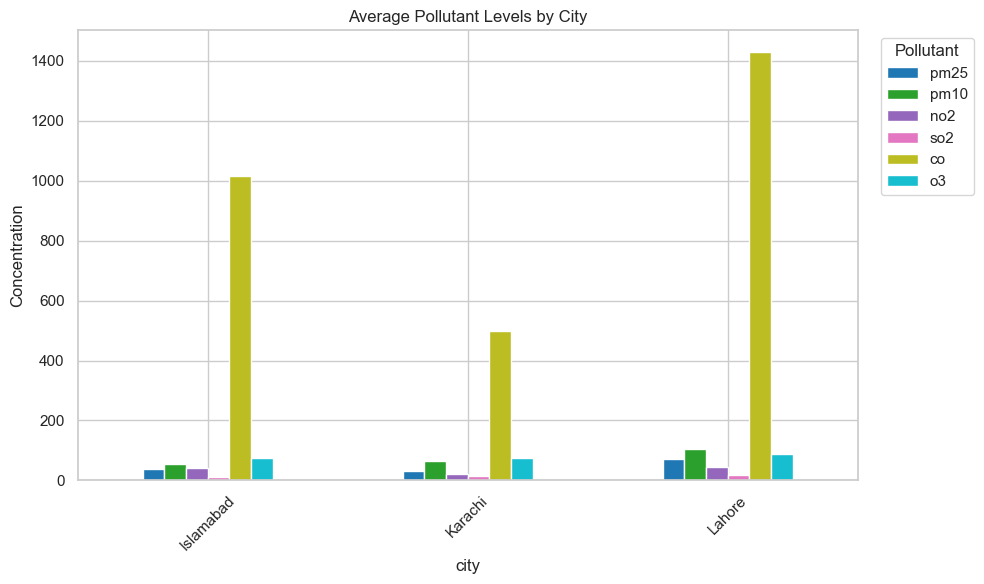

,pm25,pm10,no2,so2,co,o3
city,,,,,,
Islamabad,38.262091,55.611364,41.728552,12.563196,1015.940945,74.690818
Karachi,30.650380,63.174457,21.215108,15.967423,497.829574,74.764723
Lahore,70.290154,105.186856,43.154699,17.875356,1429.889400,87.773689


In [13]:
available_pollutants = [c for c in POLLUTANT_COLS if c in df.columns]
city_pollutant_avg = df.groupby(CITY_COL)[available_pollutants].mean()
all_stats["avg_pollutants_by_city"] = city_pollutant_avg.round(2).to_dict(orient="index")

fig, ax = plt.subplots(figsize=(max(10, n_cities * 1.3), 6))
city_pollutant_avg.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Average Pollutant Levels by City")
ax.set_ylabel("Concentration")
ax.legend(title="Pollutant", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "city_pollutant_avg.png", dpi=110, bbox_inches="tight")
plt.show()

city_pollutant_avg

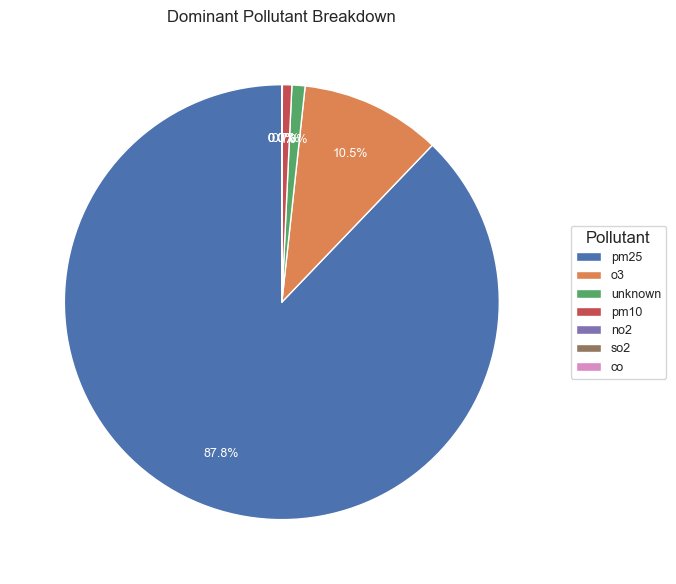

dominant_pollutant
pm25       92275
o3         10980
unknown     1023
pm10         735
no2           24
so2           15
co             2
Name: count, dtype: int64

In [16]:
counts = df["dominant_pollutant"].value_counts()
all_stats["dominant_pollutant_counts"] = counts.to_dict()

fig, ax = plt.subplots(figsize=(8, 6))
wedges, _, autotexts = ax.pie(
    counts.values,
    labels=None,                     # names hataye pie ke around se (overlap ki wajah)
    autopct="%1.1f%%",
    pctdistance=0.75,
    startangle=90,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_color("white")

ax.legend(
    wedges,
    counts.index,
    title="Pollutant",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title("Dominant Pollutant Breakdown")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "dominant_pollutant.png", dpi=110, bbox_inches="tight")
plt.show()

counts

In [15]:
with STATS_PATH.open("w", encoding="utf-8") as f:
    json.dump(
        {
            "generated_at": datetime.now(timezone.utc).isoformat(),
            "dataset_path": str(DATA_PATH),
            "shape": {"rows": df.shape[0], "columns": df.shape[1]},
            **all_stats,
        },
        f,
        indent=2,
        default=str,
    )

print(f"Stats saved -> {STATS_PATH}")

Stats saved -> ..\reports\eda\eda_stats.json
